# **ReAct Agent Intro**

ReAct = **Re**asoning + **Act**ing.
The agent loop:
  1. LLM **Reasons** about what to do next
  2. LLM **Acts** by calling a tool
  3. Tool returns a result (Observation)
  4. Repeat until LLM decides it has the final answer

Tools are just Python functions the LLM is allowed to call.

In [1]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

load_dotenv()

if os.environ.get("GROQ_API_KEY"):
    print("Bro API KEY Variable exists")
else:
    raise ValueError("GROQ_API_KEY not found")

# temperature=0.1 gives slightly more natural tool-calling behaviour
# max_tokens caps the per-turn output so the agent doesn't ramble
# timeout prevents hanging if the API is slow
llm_groq = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
)


Bro API KEY Variable exists


# **Tools**

Tools are the agent's 'hands'. Each tool has:
- A name (used by the LLM to refer to it)
- A description (tells the LLM WHEN to use it)
- An input schema (tells the LLM WHAT to pass in)

In [2]:
# TOOL 1 — Web search via DuckDuckGo (no API key needed)
# description= overrides the default — be specific so the LLM picks the right tool
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun(description="This is a tool to search the web for news")


# TOOL 2 — Wikipedia search
# WikipediaAPIWrapper handles the actual HTTP call; WikipediaQueryRun wraps it as a LangChain tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(),
    description="This is a tool to search Wikipedia"
)


# TOOL 3 — Custom 'enterprise' tool using the @tool decorator
# @tool inspects the function signature + docstring to auto-build the tool schema
# The docstring IS the description the LLM sees — write it clearly!
from langchain.tools import tool

@tool
def enterprise_tool(query: str) -> str:
    """This is a tool to send emails to employees"""
    # In reality this would call your email API
    return "Email Sent"


C:\Users\KargaomSrishanth\AppData\Local\Temp\ipykernel_29384\2450292973.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [3]:
# Collect all tools in a list — called a 'ToolKit'
# The agent will see ALL of these and choose which one to call based on the task
ToolKit = [search_tool, wikipedia_tool, enterprise_tool]
ToolKit  # print to inspect the tool objects


[DuckDuckGoSearchRun(description='This is a tool to search the web for news', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='This is a tool to search Wikipedia', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\KargaomSrishanth\\Langchain_Tutorial_Groq\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='enterprise_tool', description='This is a tool to send emails to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x0000027DD4D4A3E0>)]

# **ReAct Agent**

create_react_agent wires the LLM + tools into a full ReAct loop using LangGraph under the hood.
The graph has two nodes: 'agent' (LLM decides) and 'tools' (executes tool calls).
They loop until the LLM produces a final answer with no tool call.

C:\Users\KargaomSrishanth\AppData\Local\Temp\ipykernel_35748\3328835699.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm_groq, tools=ToolKit)


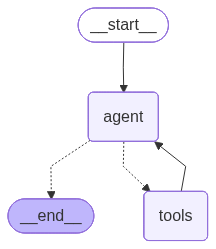

In [4]:
# create_react_agent is the high-level factory — it builds the LangGraph state machine
# Internally: LLM → if tool_call → run tool → feed result back to LLM → repeat
from langgraph.prebuilt import create_react_agent

# Pass the LLM and the list of tools — that's all you need for a basic agent
agent = create_react_agent(llm_groq, tools=ToolKit)
agent  # Displays the compiled LangGraph state machine


# **ReAct Agent Invoke With Streams**

Instead of waiting for the final answer, .stream() yields each intermediate step:
Human message → AI reasoning → Tool call → Tool result → Final AI answer.
Great for building UIs that show the agent's thinking in real time.

In [5]:
example_query = "Give me the latest news about the stock market"

# agent.stream() returns a generator — each iteration is one graph 'event'
# stream_mode='values' means each event gives you the FULL state (all messages so far)
# So event['messages'][-1] is always the LATEST message in the conversation
events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    # .pretty_print() formats the message with role labels and colour
    event["messages"][-1].pretty_print()


================================ Human Message =================================

Give me the latest news about the stock market
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (bfqf6s3ag)
 Call ID: bfqf6s3ag
  Args:
    query: latest stock market news
================================= Tool Message =================================
Name: duckduckgo_search

Stock Market News: Latest Stock news and updates on The Economic Times. Find Stock Market Live Updates, BSE, NSE Top Gainers, Losers and more. Find the latest stock market news from every corner of the globe at Reuters.com, your online source for breaking international market and finance news In-depth market analysis, real-time stock market data, research and earnings from CNBC.com. Stay updated with Moneycontrol to get latest share market news, BSE News, NSE news, Stock news, Top Gainers and Losers in Stock Market today. See the latest on US Stocks. From breaking news 

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01ktky7gpsfq69refnkx8vbdhf` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99863, Requested 1548. Please try again in 20m19.104s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

# **Manually Binding The LLM With Tools**

You don't HAVE to use the full agent loop.
Sometimes you just want the LLM to be 'tool-aware' (knows when to call a tool)
but you handle the actual tool execution yourself.

.bind_tools() is the lower-level primitive that create_react_agent uses internally.

In [ ]:
# WITHOUT binding: LLM has no tools — it can only use its training knowledge
# It cannot fetch live data, so it gives a static / possibly outdated answer
llm_groq.invoke("What's the latest news about the stock market?")


In [ ]:
# WITH binding: LLM now knows about the tools
# Instead of answering from memory, it returns tool_calls in the AIMessage
# — telling you WHICH tool to call and with WHAT arguments
# You are responsible for executing those calls and feeding results back
llm_binded = llm_groq.bind_tools(ToolKit)
llm_binded.invoke("What's the latest news about the stock market?")
# Notice: content='' but tool_calls=[{name: 'duckduckgo_search', args: {...}}]
